In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error

In [8]:
train = pd.read_csv("../data/stock_9_train.csv")
test = pd.read_csv("../data/stock_9_test.csv")

print(f"Train: {train.shape[0]} rows, {train.shape[1]-1} features")
print(f"Test: {test.shape[0]} row")
train.head()

Train: 59 rows, 20 features
Test: 1 row


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,target
0,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,0.746087,-1.001019,...,-1.429155,-0.726697,-1.818919,-0.692331,0.204809,1.196650,-0.005144,-0.849170,-1.123597,155.855544
1,-0.378163,1.299228,-0.356264,0.737516,-0.933618,-0.205438,-0.950022,-0.339033,0.452581,0.964805,...,-0.640065,-0.328064,-0.134612,-0.973872,-0.518885,0.523591,-0.687967,0.509695,1.074506,197.324896
2,-0.096179,1.128019,-2.280738,-1.496639,-0.922886,1.461179,0.282587,0.767317,-1.268424,0.863452,...,1.849634,2.143520,-0.316339,0.745343,1.237368,-2.055713,-0.058003,1.479600,1.369194,195.239400
3,0.389692,0.102553,-0.147442,1.588276,-0.622207,2.060298,-0.225431,-1.277016,1.423416,-0.296014,...,2.428758,2.191645,-0.401731,-1.430537,-0.504904,1.551928,-0.273643,0.195066,0.306481,214.993209
4,-0.238174,-0.266387,0.232170,-0.555327,0.471539,1.012716,0.155429,0.351756,-1.616011,-0.515828,...,1.757643,1.932551,0.185588,0.763269,0.544957,-1.250413,-0.650461,-0.370719,-0.916821,198.696230


In [9]:
train.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,target
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,...,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,-0.142198,-0.015563,0.001326,-0.134126,-0.201732,-0.037611,0.100979,0.059867,-0.156154,-0.075237,...,-0.020514,-0.015070,-0.283670,0.009751,0.064974,-0.212012,-0.071718,-0.026711,-0.126502,218.603005
std,1.417661,0.902923,1.026524,0.925263,1.000530,0.959680,1.108441,0.952149,1.002627,0.997424,...,1.171322,1.052823,1.093463,1.090568,1.206156,1.032803,1.033040,0.947330,0.984640,43.741755
min,-7.912183,-2.319611,-2.280738,-2.116654,-2.964529,-2.063238,-2.180210,-2.930594,-2.433342,-2.913633,...,-2.627166,-1.678054,-3.818406,-3.031544,-2.826230,-2.492867,-2.543323,-2.587662,-2.749768,80.000000
25%,-0.663143,-0.727257,-0.692495,-0.696561,-0.850537,-0.538474,-0.601600,-0.446846,-1.085006,-0.689798,...,-0.766754,-0.794538,-0.932500,-0.740837,-0.722194,-1.045407,-0.669214,-0.738951,-0.841157,199.124084
50%,-0.051197,0.035576,0.091520,-0.109727,-0.081588,-0.159185,0.030917,0.052467,-0.064253,-0.007982,...,-0.086041,-0.207123,-0.187394,0.111519,0.062923,-0.032515,-0.037573,0.049409,-0.240657,215.197963
75%,0.471757,0.630228,0.719290,0.624496,0.401571,0.661043,0.716503,0.520243,0.624009,0.495150,...,0.580729,0.844402,0.267137,0.672316,0.797807,0.529321,0.629533,0.578445,0.594531,235.585653
max,1.905060,1.454050,2.128470,1.588276,2.129247,2.060298,3.178854,1.937231,1.633685,1.987220,...,2.889189,2.191645,2.213364,2.314337,3.268441,1.551928,1.745678,1.732123,1.843020,400.000000


0 null columns


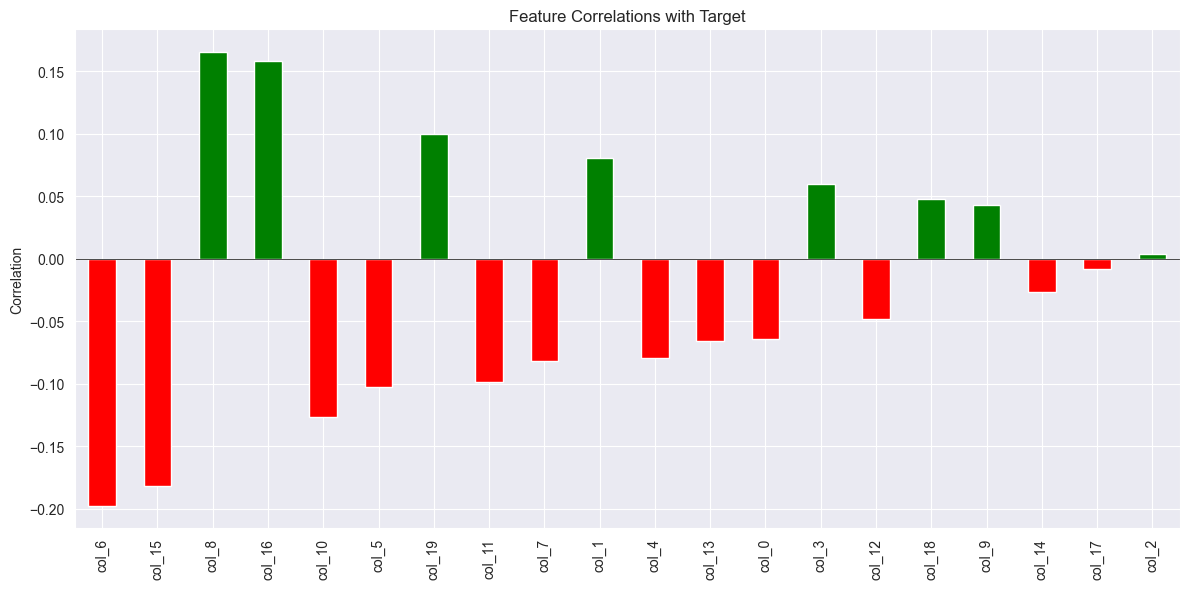

col_6    -0.197423
col_15   -0.181759
col_8     0.165398
col_16    0.158590
col_10   -0.126323
col_5    -0.102835
col_19    0.099871
col_11   -0.098564
col_7    -0.081644
col_1     0.080349
col_4    -0.079117
col_13   -0.066080
col_0    -0.063985
col_3     0.060221
col_12   -0.048049
col_18    0.047709
col_9     0.043401
col_14   -0.026431
col_17   -0.008291
col_2     0.003541
Name: target, dtype: float64


In [10]:
print(train.isnull().any().sum(), "null columns")

corr = train.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 6))
corr.plot(kind='bar', color=['red' if x < 0 else 'green' for x in corr])
plt.title('Feature Correlations with Target')
plt.ylabel('Correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(corr)

In [11]:
y = train['target']

corrs = train.corr()['target'].drop('target')
strong = list(corrs[corrs.abs() > 0.1].index)
weak = list(corrs[corrs.abs() <= 0.1].index)

print(f"Strong features ({len(strong)}): {strong}")
print(f"Weak/noise features ({len(weak)}): {weak}")

models = {
    'Linear (all 20)': (LinearRegression(), train.drop('target', axis=1).columns.tolist()),
    'Linear (strong)': (LinearRegression(), strong),
    'Ridge a=1 (all)': (Ridge(alpha=1), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=10 (all)': (Ridge(alpha=10), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=100 (all)': (Ridge(alpha=100), train.drop('target', axis=1).columns.tolist()),
    'Ridge a=100 (strong)': (Ridge(alpha=100), strong),
    'Mean baseline': (None, None),
}

print(f"\n{'Model':<25} {'CV RMSE':>10}")
print("-" * 37)

for name, (model, cols) in models.items():
    if model is None:
        rmse = y.std()
        print(f"{name:<25} {rmse:>10.2f}  (baseline)")
        continue
    X_m = train[cols]
    cv = min(5, len(train))
    scores = cross_val_score(model, X_m, y, cv=cv, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    print(f"{name:<25} {rmse:>10.2f}")

Strong features (6): ['col_5', 'col_6', 'col_8', 'col_10', 'col_15', 'col_16']
Weak/noise features (14): ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_7', 'col_9', 'col_11', 'col_12', 'col_13', 'col_14', 'col_17', 'col_18', 'col_19']

Model                        CV RMSE
-------------------------------------
Linear (all 20)                75.47
Linear (strong)                51.04
Ridge a=1 (all)                63.83
Ridge a=10 (all)               52.13
Ridge a=100 (all)              47.44
Ridge a=100 (strong)           45.82
Mean baseline                  43.74  (baseline)


In [12]:
# Is there ANY signal at all? Check with LOO CV on minimal models
loo = LeaveOneOut()

minimal = {
    'Mean': (None, None),
    'Linear (col_6 only)': (LinearRegression(), ['col_6']),
    'Linear (col_6 + col_15)': (LinearRegression(), ['col_6', 'col_15']),
    'Ridge a=100 (top 3)': (Ridge(alpha=100), ['col_6', 'col_15', 'col_8']),
    'Ridge a=100 (strong 6)': (Ridge(alpha=100), strong),
}

print(f"{'Model':<30} {'LOO RMSE':>10}")
print("-" * 42)

for name, (model, cols) in minimal.items():
    if model is None:
        rmse = y.std()
        print(f"{name:<30} {rmse:>10.2f}  (baseline)")
        continue
    X_m = train[cols]
    scores = cross_val_score(model, X_m, y, cv=loo, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    print(f"{name:<30} {rmse:>10.2f}")

Model                            LOO RMSE
------------------------------------------
Mean                                43.74  (baseline)
Linear (col_6 only)                 43.82
Linear (col_6 + col_15)             44.90
Ridge a=100 (top 3)                 43.84
Ridge a=100 (strong 6)              44.36


In [13]:
prediction = y.mean()
sigma = y.std()

print(f"Final model: PREDICT THE MEAN")
print(f"No features used — no model beats the baseline")
print(f"\nPredicted target: {prediction:.4f}")
print(f"Noise σ: {sigma:.2f}")

print(f"\n1 SD range: [{prediction - sigma:.2f}, {prediction + sigma:.2f}]")
print(f"2 SD range: [{prediction - 2*sigma:.2f}, {prediction + 2*sigma:.2f}]")
print(f"3 SD range: [{prediction - 3*sigma:.2f}, {prediction + 3*sigma:.2f}]")

Final model: PREDICT THE MEAN
No features used — no model beats the baseline

Predicted target: 218.6030
Noise σ: 43.74

1 SD range: [174.86, 262.34]
2 SD range: [131.12, 306.09]
3 SD range: [87.38, 349.83]
